# LMSYS Chatbot Arena — Exploratory Data Analysis
Understand the competition data before building models.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
# Load data — adjust path for Kaggle vs local
import os
if os.path.exists('/kaggle/input/lmsys-chatbot-arena/train.csv'):
    DATA_DIR = '/kaggle/input/lmsys-chatbot-arena'
else:
    DATA_DIR = '../data'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')
print(f'Sub:   {sub.shape}')

Train: (57477, 9)
Test:  (3, 4)
Sub:   (3, 4)


In [4]:
train.head(2)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              57477 non-null  int64
 1   model_a         57477 non-null  str  
 2   model_b         57477 non-null  str  
 3   prompt          57477 non-null  str  
 4   response_a      57477 non-null  str  
 5   response_b      57477 non-null  str  
 6   winner_model_a  57477 non-null  int64
 7   winner_model_b  57477 non-null  int64
 8   winner_tie      57477 non-null  int64
dtypes: int64(4), str(5)
memory usage: 3.9 MB


In [6]:
# Check for missing values
print('Missing values in train:')
print(train.isnull().sum())
print('\nMissing values in test:')
print(test.isnull().sum())

Missing values in train:
id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64

Missing values in test:
id            0
prompt        0
response_a    0
response_b    0
dtype: int64


## Target Distribution

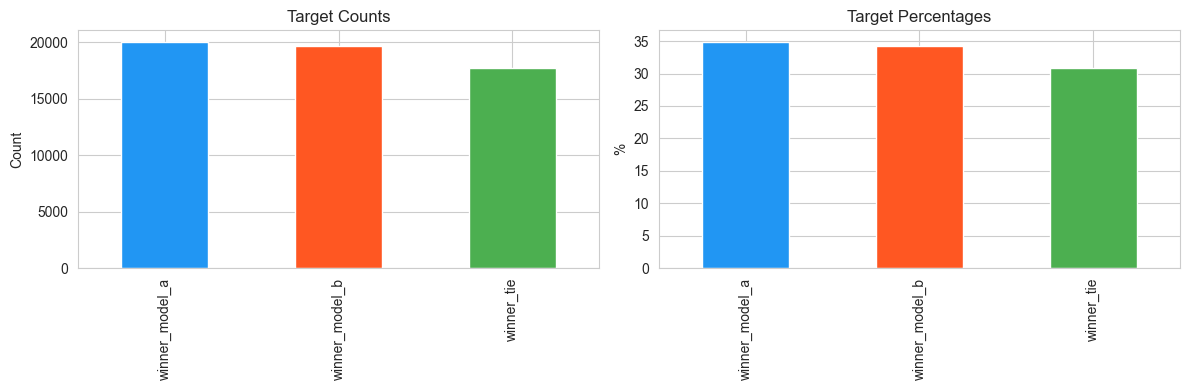

winner_model_a: 20,064 (34.9%)
winner_model_b: 19,652 (34.2%)
winner_tie: 17,761 (30.9%)


In [7]:
target_cols = ['winner_model_a', 'winner_model_b', 'winner_tie']
target_dist = train[target_cols].sum()
target_pct = target_dist / len(train) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_dist.plot(kind='bar', ax=axes[0], color=['#2196F3', '#FF5722', '#4CAF50'])
axes[0].set_title('Target Counts')
axes[0].set_ylabel('Count')

target_pct.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF5722', '#4CAF50'])
axes[1].set_title('Target Percentages')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

for col, cnt, pct in zip(target_cols, target_dist, target_pct):
    print(f'{col}: {cnt:,.0f} ({pct:.1f}%)')

## Multi-turn Conversation Structure
The `prompt`, `response_a`, `response_b` columns are JSON-encoded lists (multi-turn).

Number of turns distribution:
num_turns
1     49938
2      4673
3      1485
4       607
5       311
6       167
7       103
8        60
9        44
10       29
11       16
12       14
13        5
14        3
15        4
16        2
17        3
18        1
19        4
20        2
21        1
22        1
29        1
32        1
35        1
36        1
Name: count, dtype: int64


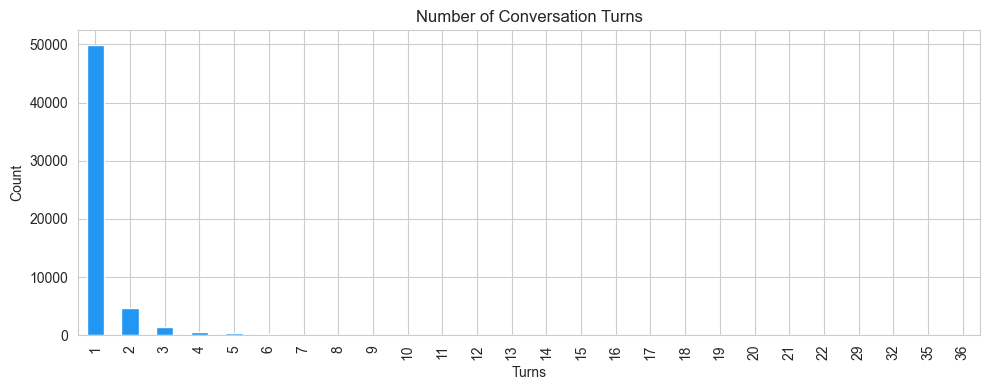

In [8]:
# Parse JSON and count turns
train['num_turns'] = train['prompt'].apply(lambda x: len(json.loads(x)))

print('Number of turns distribution:')
print(train['num_turns'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 4))
train['num_turns'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#2196F3')
ax.set_title('Number of Conversation Turns')
ax.set_xlabel('Turns')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# Example multi-turn conversation
idx = train[train['num_turns'] > 1].index[0]
prompts = json.loads(train.loc[idx, 'prompt'])
resp_a = json.loads(train.loc[idx, 'response_a'])
resp_b = json.loads(train.loc[idx, 'response_b'])

print(f'Example row {idx} — {len(prompts)} turns:')
for i in range(len(prompts)):
    print(f'\n--- Turn {i+1} ---')
    print(f'PROMPT:     {prompts[i][:200]}...' if len(prompts[i]) > 200 else f'PROMPT:     {prompts[i]}')
    print(f'RESPONSE A: {resp_a[i][:200]}...' if len(resp_a[i]) > 200 else f'RESPONSE A: {resp_a[i]}')
    print(f'RESPONSE B: {resp_b[i][:200]}...' if len(resp_b[i]) > 200 else f'RESPONSE B: {resp_b[i]}')

Example row 0 — 2 turns:

--- Turn 1 ---
PROMPT:     Is it morally right to try to have a certain percentage of females on managerial positions?
RESPONSE A: The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity,...
RESPONSE B: As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue that su...

--- Turn 2 ---
PROMPT:     OK, does pineapple belong on a pizza? Relax and give me fun answer.
RESPONSE A: Ah, the age-old culinary conundrum that has divided nations and dinner tables: does pineapple belong on a pizza? The tropical twist of pineapple on pizza, known as Hawaiian pizza, is a hotly debated t...
RESPONSE B: As an AI, I don't eat, so I don't have personal preferences. But, in the world of pizza, the pineap

## Text Length Statistics

In [10]:
# Character lengths of full JSON strings
for col in ['prompt', 'response_a', 'response_b']:
    train[f'{col}_len'] = train[col].str.len()

train['total_len'] = train['prompt_len'] + train['response_a_len'] + train['response_b_len']

len_cols = ['prompt_len', 'response_a_len', 'response_b_len', 'total_len']
print(train[len_cols].describe().round(0).astype(int))

       prompt_len  response_a_len  response_b_len  total_len
count       57477           57477           57477      57477
mean          369            1378            1386       3133
std          1073            1514            1538       3232
min             7               4               4         26
25%            52             408             413       1218
50%            96            1076            1086       2447
75%           243            1862            1873       3967
max         33056           54058           53830      76468


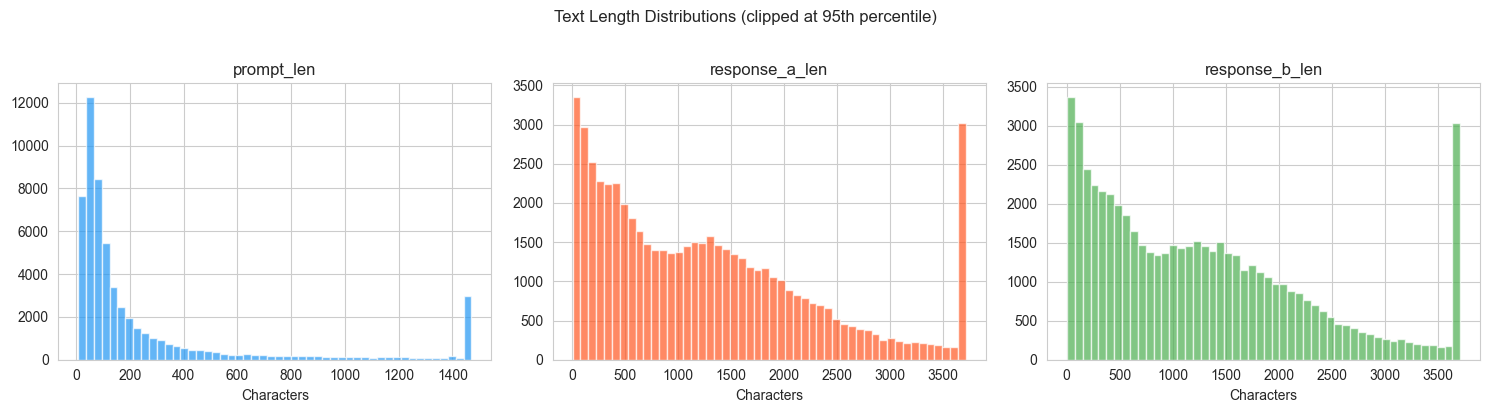

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['prompt_len', 'response_a_len', 'response_b_len'],
                           ['#2196F3', '#FF5722', '#4CAF50']):
    train[col].clip(upper=train[col].quantile(0.95)).hist(bins=50, ax=ax, color=color, alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('Characters')

plt.suptitle('Text Length Distributions (clipped at 95th percentile)', y=1.02)
plt.tight_layout()
plt.show()

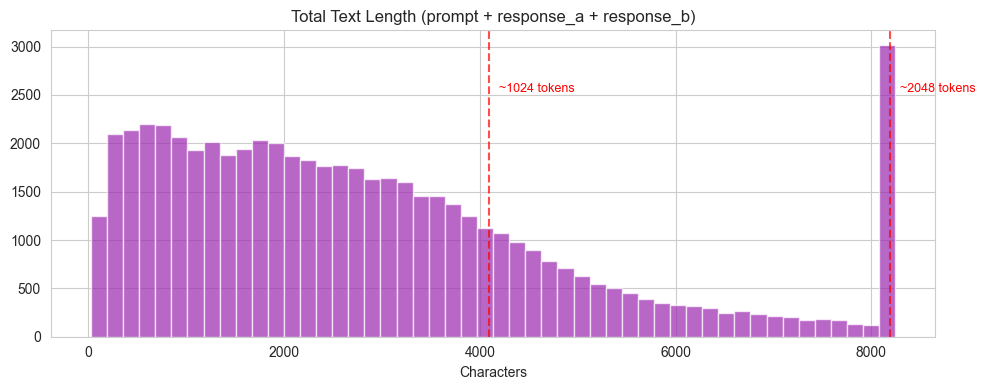

23.4% of rows exceed ~1024 tokens
5.1% of rows exceed ~2048 tokens
2.0% of rows exceed ~3072 tokens
0.9% of rows exceed ~4096 tokens


In [12]:
# Total length distribution — this matters for token truncation
fig, ax = plt.subplots(figsize=(10, 4))
train['total_len'].clip(upper=train['total_len'].quantile(0.95)).hist(bins=50, ax=ax, color='#9C27B0', alpha=0.7)
ax.set_title('Total Text Length (prompt + response_a + response_b)')
ax.set_xlabel('Characters')

# Approximate token count markers (1 token ≈ 4 chars)
for tokens, label in [(1024*4, '~1024 tokens'), (2048*4, '~2048 tokens')]:
    ax.axvline(x=tokens, color='red', linestyle='--', alpha=0.7)
    ax.text(tokens+100, ax.get_ylim()[1]*0.8, label, fontsize=9, color='red')

plt.tight_layout()
plt.show()

for t in [1024, 2048, 3072, 4096]:
    pct = (train['total_len'] > t * 4).mean() * 100
    print(f'{pct:.1f}% of rows exceed ~{t} tokens')

## Model Distribution (Train only)

Unique model_a: 64
Unique model_b: 64

Total unique models: 64


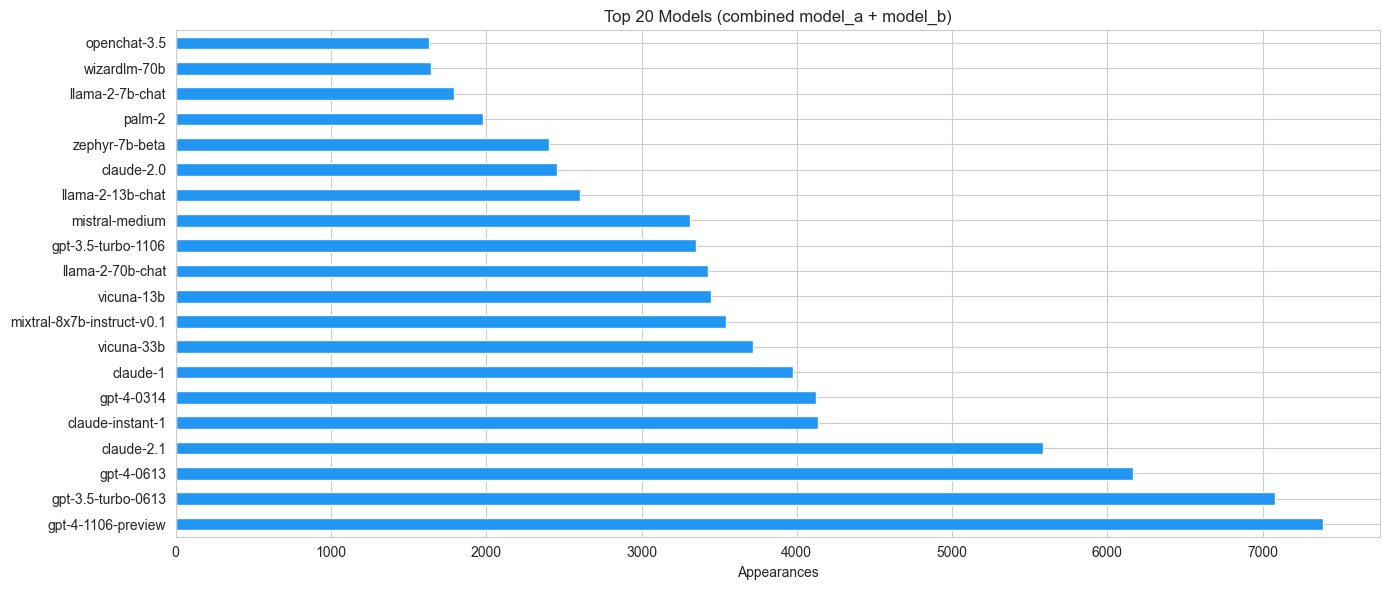

In [13]:
if 'model_a' in train.columns:
    print(f'Unique model_a: {train["model_a"].nunique()}')
    print(f'Unique model_b: {train["model_b"].nunique()}')
    all_models = pd.concat([train['model_a'], train['model_b']]).value_counts()
    print(f'\nTotal unique models: {all_models.index.nunique()}')

    fig, ax = plt.subplots(figsize=(14, 6))
    all_models.head(20).plot(kind='barh', ax=ax, color='#2196F3')
    ax.set_title('Top 20 Models (combined model_a + model_b)')
    ax.set_xlabel('Appearances')
    plt.tight_layout()
    plt.show()
else:
    print('model_a/model_b not in train columns')

## Response Length Difference vs. Winner
Longer responses often win (verbosity bias).

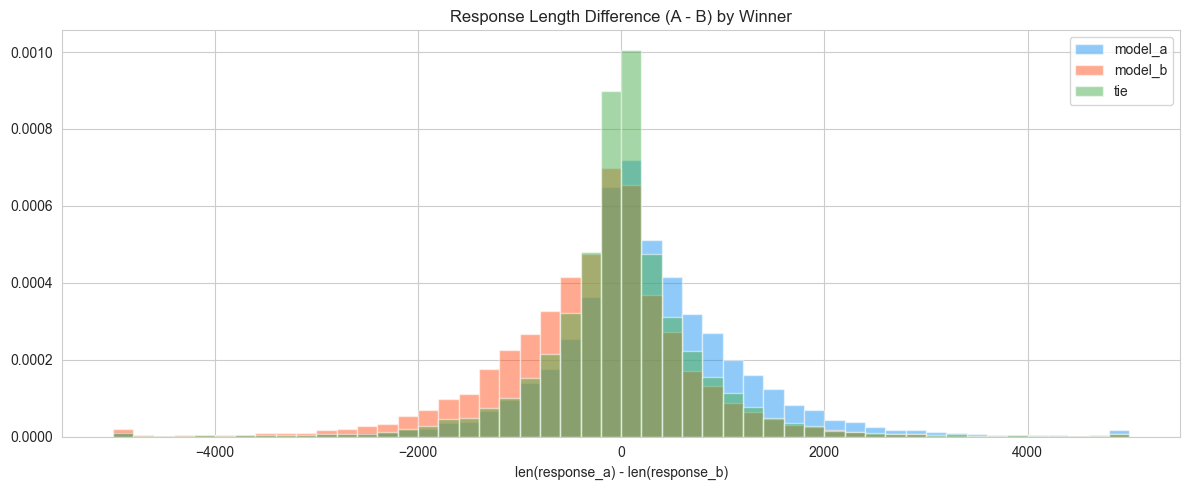


Mean response length by winner:
         response_a_len  response_b_len
winner                                 
model_a            1568            1314
model_b            1291            1569
tie                1259            1265


In [14]:
train['len_diff'] = train['response_a_len'] - train['response_b_len']

# Create winner label
train['winner'] = 'tie'
train.loc[train['winner_model_a'] == 1, 'winner'] = 'model_a'
train.loc[train['winner_model_b'] == 1, 'winner'] = 'model_b'

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in [('model_a', '#2196F3'), ('model_b', '#FF5722'), ('tie', '#4CAF50')]:
    subset = train[train['winner'] == label]['len_diff'].clip(-5000, 5000)
    subset.hist(bins=50, ax=ax, alpha=0.5, label=label, color=color, density=True)

ax.set_title('Response Length Difference (A - B) by Winner')
ax.set_xlabel('len(response_a) - len(response_b)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nMean response length by winner:')
print(train.groupby('winner')[['response_a_len', 'response_b_len']].mean().round(0).astype(int))

## Naive Baseline — Constant Prediction
What log loss do we get by predicting class frequencies?

In [15]:
from sklearn.metrics import log_loss

y_true = train[target_cols].values

# Baseline 1: uniform 1/3
y_pred_uniform = np.full_like(y_true, 1/3, dtype=float)
ll_uniform = log_loss(y_true, y_pred_uniform)
print(f'Uniform (1/3, 1/3, 1/3) log loss: {ll_uniform:.4f}')

# Baseline 2: class frequencies
freq = y_true.mean(axis=0)
y_pred_freq = np.tile(freq, (len(y_true), 1))
ll_freq = log_loss(y_true, y_pred_freq)
print(f'Class frequency baseline log loss: {ll_freq:.4f}')
print(f'  frequencies: {freq.round(4)}')

Uniform (1/3, 1/3, 1/3) log loss: 1.0986
Class frequency baseline log loss: 1.0972
  frequencies: [0.3491 0.3419 0.309 ]


## Submission Format Check

In [16]:
print('Sample submission:')
print(sub.head())
print(f'\nShape: {sub.shape}')
print(f'Columns: {list(sub.columns)}')
print(f'Test IDs match submission IDs: {set(test["id"].values) == set(sub["id"].values)}')

Sample submission:
        id  winner_model_a  winner_model_b  winner_tie
0   136060        0.333333        0.333333    0.333333
1   211333        0.333333        0.333333    0.333333
2  1233961        0.333333        0.333333    0.333333

Shape: (3, 4)
Columns: ['id', 'winner_model_a', 'winner_model_b', 'winner_tie']
Test IDs match submission IDs: True


## Key Takeaways

Run this notebook to see:
1. **Target distribution** - ~40/40/20 split (A/B/tie)
2. **Many conversations are single-turn** - but multi-turn exists
3. **Text lengths vary widely** - truncation strategy matters
4. **Verbosity bias** - longer responses tend to win
5. **Naive baselines** give log loss ~1.05-1.10. Competition winners achieve ~0.87